<a href="https://colab.research.google.com/github/miftahulhdd/BigData26_B_2411533005_MiftahulHudaAmri/blob/main/praktikum04/BD_B_P04_2411533005_MiftahulHudaAmri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Langkah Praktikum

Menyiapkan Lingkungan dan Data Contoh

In [ ]:
!pip install -q duckdb networkx shapely tinydb "deltalake>=1.0"

from google.colab import drive

drive.mount("/content/drive")

import os
import glob
import zipfile

DIR_P3 = "/content/drive/MyDrive/BigData/Praktikum3"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum4"
TRIPS_BERSIH = f"{DIR_P3}/trips_bersih"  # hasil Praktikum 3 (K-10)
ZIP_TRIPS = f"{DIR_P3}/trips_bersih.zip"

os.makedirs(DIR_SIMPAN, exist_ok=True)


def siapkan_trips_bersih():
    """Ekstrak trips_bersih.zip bila folder trips_bersih/ belum ada."""
    if os.path.isdir(TRIPS_BERSIH) and glob.glob(f"{TRIPS_BERSIH}/**/*.parquet", recursive=True):
        print("Folder trips_bersih/ sudah ada, ekstraksi dilewati.")
        return

    assert os.path.exists(ZIP_TRIPS), (
        f"Tidak ada folder trips_bersih/ maupun file {ZIP_TRIPS}. "
        "Periksa DIR_P3 atau pakai K-1b."
    )

    with zipfile.ZipFile(ZIP_TRIPS) as z:
        nama = [n for n in z.namelist() if not n.startswith("__MACOSX")]
        # Zip yang sudah berisi folder trips_bersih/ di dalamnya -> ekstrak ke DIR_P3
        # Zip yang langsung berisi folder partisi (borough_naik=...) -> ekstrak ke TRIPS_BERSIH
        if all(n.startswith("trips_bersih/") for n in nama):
            tujuan = DIR_P3
        else:
            tujuan = TRIPS_BERSIH
        print(f"Mengekstrak {ZIP_TRIPS} -> {tujuan} ...")
        z.extractall(tujuan, members=nama)

    print("Selesai ekstrak.")


siapkan_trips_bersih()

assert os.path.exists(TRIPS_BERSIH), \
    "Folder trips_bersih/ tidak ada. Jalankan ulang P3/K-10 atau pakai K-1b."

n_pq = len(glob.glob(f"{TRIPS_BERSIH}/**/*.parquet", recursive=True))
print("file parquet ditemukan:", n_pq)
assert n_pq > 0, "Folder ada tetapi tidak berisi file .parquet. Periksa isi zip."

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 21.1 MB/s eta 0:00:00
Mounted at /content/drive
Folder trips_bersih/ sudah ada, ekstraksi dilewati.
file parquet ditemukan: 8


In [ ]:
import os
import time
import json
import sqlite3
import random
import shutil
import glob

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds


# Pengukur waktu (dari Praktikum 1/K-3, versi ringkas)
catatan = []


def ukur(label, fungsi):
    t0 = time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({"langkah": label, "detik": round(detik, 4)})
    print(f"[{label}] {detik:.4f} s")
    return hasil


def baca_trips(path):
    """Baca folder Parquet berpartisi tanpa tipe dictionary
    (menghindari ArrowInvalid: Cannot yet unify dictionaries with nulls)."""
    dataset = ds.dataset(
        path,
        format="parquet",
        partitioning=ds.partitioning(flavor="hive"),  # kolom partisi dibaca sebagai string biasa
    )
    tabel = dataset.to_table()

    # Jaga-jaga: bila ada kolom di dalam file yang bertipe dictionary, ubah ke tipe aslinya
    for i, f in enumerate(tabel.schema):
        if pa.types.is_dictionary(f.type):
            tabel = tabel.set_column(i, f.name, tabel.column(i).cast(f.type.value_type))

    return tabel.to_pandas()


df = ukur("baca trips_bersih", lambda: baca_trips(TRIPS_BERSIH))


# Ganti nama kolom asli data TLC menjadi nama yang lebih mudah dibaca
NAMA_BARU = {
    "tpep_pickup_datetime": "waktu_jemput",
    "PULocationID": "zona_jemput",
    "DOLocationID": "zona_tujuan",
    "borough_naik": "wilayah_jemput",
    "trip_distance": "jarak_mil",
    "total_amount": "total_bayar",
    "tip_amount": "tip",
    "nama_pembayaran": "metode_bayar",
}

df = df.rename(columns=NAMA_BARU)

df["wilayah_jemput"] = df["wilayah_jemput"].astype(str)

print("baris:", f"{len(df):,}", "| kolom:", df.shape[1])


# Contoh 300.000 baris untuk K-2 dan K-3 (agar tidak terlalu lama)
sample = df.sample(
    n=min(300_000, len(df)),
    random_state=42
).reset_index(drop=True)

sample["id_perjalanan"] = sample.index + 1
sample["waktu_jemput"] = sample["waktu_jemput"].astype(str)

[baca trips_bersih] 8.6625 s
baris: 2,986,910 | kolom: 18


Tabel Biasa vs Key-value

In [ ]:
KOLOM = [
    "id_perjalanan",
    "waktu_jemput",
    "zona_jemput",
    "zona_tujuan",
    "wilayah_jemput",
    "jarak_mil",
    "total_bayar",
    "metode_bayar"
]

data = sample[KOLOM].copy()


# Model 1 - relasional: tabel SQLite
if os.path.exists("uji.db"):
    os.remove("uji.db")

con = sqlite3.connect("uji.db")

ukur(
    "relasional: muat tabel",
    lambda: data.to_sql("perjalanan", con, index=False)
)


# Model 2 - key-value: kamus (dict) dengan kunci "perjalanan:<id>", nilainya teks JSON
def bangun_kv():
    return {
        f"perjalanan:{r['id_perjalanan']}": json.dumps(r)
        for r in data.to_dict("records")
    }


kv = ukur("key-value: bangun dict", bangun_kv)

print("jumlah key:", len(kv))


# Pertanyaan A: ambil SATU perjalanan berdasarkan id (200 id acak)
random.seed(42)

id_uji = random.sample(range(1, len(data) + 1), 200)


def cari_sql():
    cur = con.cursor()
    return [
        cur.execute(
            "SELECT * FROM perjalanan WHERE id_perjalanan = ?",
            (i,)
        ).fetchone()
        for i in id_uji
    ]


def cari_kv():
    return [json.loads(kv[f"perjalanan:{i}"]) for i in id_uji]


r1 = ukur(
    "cari 200 perjalanan - SQL tanpa indeks",
    cari_sql
)

con.execute("CREATE INDEX idx_id ON perjalanan(id_perjalanan)")  # buat indeks

r2 = ukur(
    "cari 200 perjalanan - SQL dengan indeks",
    cari_sql
)

r3 = ukur(
    "cari 200 perjalanan - key-value",
    cari_kv
)

print(
    "hasil sama?",
    r1[0][0] == r2[0][0] == r3[0]["id_perjalanan"]
)


# Pertanyaan B: hitung rata-rata total bayar per wilayah (melibatkan SEMUA data)
def hitung_sql():
    return con.execute(
        """SELECT wilayah_jemput, COUNT(*), ROUND(AVG(total_bayar), 2)
        FROM perjalanan
        GROUP BY wilayah_jemput
        ORDER BY 2 DESC, 1"""
    ).fetchall()


def hitung_kv():
    total, jumlah = {}, {}

    for teks in kv.values():
        d = json.loads(teks)  # setiap nilai harus dibuka dulu
        w = d["wilayah_jemput"]

        total[w] = total.get(w, 0) + d["total_bayar"]
        jumlah[w] = jumlah.get(w, 0) + 1

    return sorted(
        [
            (w, jumlah[w], round(total[w] / jumlah[w], 2))
            for w in jumlah
        ],
        key=lambda x: (-x[1], x[0])
    )


h1 = ukur(
    "hitung per wilayah - SQL GROUP BY",
    hitung_sql
)

h2 = ukur(
    "hitung per wilayah - key-value (buka semua nilai)",
    hitung_kv
)

print(h1[:3])

print("hasil sama?", h1 == h2)

[relasional: muat tabel] 2.9521 s
[key-value: bangun dict] 8.7616 s
jumlah key: 300000
[cari 200 perjalanan - SQL tanpa indeks] 6.9061 s
[cari 200 perjalanan - SQL dengan indeks] 0.0042 s
[cari 200 perjalanan - key-value] 0.0014 s
hasil sama? True
[hitung per wilayah - SQL GROUP BY] 0.2002 s
[hitung per wilayah - key-value (buka semua nilai)] 1.2710 s
[('Manhattan', 267034, 22.7), ('Queens', 27288, 70.34), ('Unknown', 3787, 39.13)]
hasil sama? True


Document: Bentuk Data yang Fleksibel

In [ ]:
from tinydb import TinyDB, Query
from tinydb.storages import MemoryStorage


def ke_dokumen(r):
    dok = {
        "id_perjalanan": int(r.id_perjalanan),
        "waktu_jemput": r.waktu_jemput,
        "jemput": {
            "zona": int(r.zona_jemput),
            "wilayah": r.wilayah_jemput
        },
        "tujuan": {
            "zona": int(r.zona_tujuan)
        },
        "biaya": {
            "jarak_mil": float(r.jarak_mil),
            "total": float(r.total_bayar),
            "metode_bayar": r.metode_bayar
        },
    }

    # Tip hanya dicatat untuk pembayaran kartu -> field ini ada di sebagian dokumen saja
    if r.metode_bayar == "Kartu kredit":
        dok["biaya"]["tip"] = float(r.tip)

    return dok


db = TinyDB(storage=MemoryStorage)

tabel = db.table("perjalanan")

docs = [
    ke_dokumen(r)
    for r in sample.head(20_000).itertuples()
]

tabel.insert_multiple(docs)

print("jumlah dokumen:", len(tabel))

print(json.dumps(tabel.all()[0], indent=2))

jumlah dokumen: 20000
{
  "id_perjalanan": 1,
  "waktu_jemput": "2023-01-16 10:40:39",
  "jemput": {
    "zona": 48,
    "wilayah": "Manhattan"
  },
  "tujuan": {
    "zona": 164
  },
  "biaya": {
    "jarak_mil": 1.55,
    "total": 19.32,
    "metode_bayar": "Kartu kredit",
    "tip": 3.22
  }
}


In [ ]:
Q = Query()

print(
    "jemput di Manhattan & total > 50 :",
    len(
        tabel.search(
            (Q.jemput.wilayah == "Manhattan") &
            (Q.biaya.total > 50)
        )
    )
)

print(
    "dokumen yang punya field tip :",
    len(tabel.search(Q.biaya.tip.exists()))
)

print(
    "dokumen yang TIDAK punya tip :",
    len(tabel.search(~Q.biaya.tip.exists()))
)


# Menambah field baru ("cuaca") pada satu dokumen - tanpa mengubah struktur apa pun
tabel.insert({
    "id_perjalanan": 999_999,
    "waktu_jemput": "2023-01-15 08:00:00",
    "jemput": {
        "zona": 161,
        "wilayah": "Manhattan"
    },
    "tujuan": {
        "zona": 236
    },
    "biaya": {
        "jarak_mil": 1.2,
        "total": 14.5,
        "metode_bayar": "Kartu kredit",
        "tip": 3.0
    },
    "cuaca": {
        "hujan": True,
        "suhu_c": -2.0
    }
})

print(
    "dokumen yang punya field cuaca :",
    len(tabel.search(Q.cuaca.exists()))
)

print(
    "total dokumen sekarang :",
    len(tabel)
)

jemput di Manhattan & total > 50 : 693
dokumen yang punya field tip : 15906
dokumen yang TIDAK punya tip : 4094
dokumen yang punya field cuaca : 1
total dokumen sekarang : 20001


Penyimpanan per Kolom: DuckDB pada Parquet

In [ ]:
import duckdb

GLOB = f"{TRIPS_BERSIH}/*/*.parquet"

con_d = duckdb.connect()


# VIEW = "jendela" bernama yang membaca Parquet langsung (tidak menyalin data).
# Di sinilah nama kolom asli TLC diberi nama yang mudah dibaca.
con_d.sql(f"""
    CREATE VIEW perjalanan AS
    SELECT
        tpep_pickup_datetime AS waktu_jemput,
        PULocationID AS zona_jemput,
        DOLocationID AS zona_tujuan,
        borough_naik AS wilayah_jemput,
        trip_distance AS jarak_mil,
        total_amount AS total_bayar,
        nama_pembayaran AS metode_bayar
    FROM read_parquet('{GLOB}', hive_partitioning=true)
""")


SQL = """
    SELECT
        wilayah_jemput,
        COUNT(*) AS jumlah,
        ROUND(AVG(total_bayar), 2) AS rata_bayar
    FROM perjalanan
    GROUP BY wilayah_jemput
    ORDER BY jumlah DESC, wilayah_jemput
"""

hasil_d = ukur(
    "DuckDB - hitung per wilayah (langsung dari Parquet)",
    lambda: con_d.sql(SQL).df()
)

print(hasil_d)


# Pembanding: SQLite (menyimpan per baris) pada data yang sama
KOLOM_S = [
    "wilayah_jemput",
    "total_bayar",
    "jarak_mil",
    "zona_jemput",
    "zona_tujuan"
]

if os.path.exists("baris.db"):
    os.remove("baris.db")

con_s = sqlite3.connect("baris.db")

ukur(
    "SQLite - muat seluruh baris ke tabel",
    lambda: df[KOLOM_S].to_sql(
        "perjalanan",
        con_s,
        index=False
    )
)

hasil_s = ukur(
    "SQLite - hitung per wilayah",
    lambda: con_s.execute(
        """
        SELECT wilayah_jemput, COUNT(*), ROUND(AVG(total_bayar), 2)
        FROM perjalanan
        GROUP BY wilayah_jemput
        ORDER BY 2 DESC, 1
        """
    ).fetchall()
)

print(
    "hasil sama?",
    [tuple(r) for r in hasil_d.itertuples(index=False)] == [tuple(r) for r in hasil_s]
)

[DuckDB - hitung per wilayah (langsung dari Parquet)] 0.2660 s
               wilayah_jemput   jumlah  rata_bayar
0                   Manhattan  2659609       22.72
1                      Queens   270315       70.46
2                     Unknown    37609       39.24
3                    Brooklyn    15724       32.72
4                       Bronx     3074       34.44
5  __HIVE_DEFAULT_PARTITION__      340       74.72
6               Staten Island      211       74.07
7                         EWR       28      106.41
[SQLite - muat seluruh baris ke tabel] 6.7023 s
[SQLite - hitung per wilayah] 4.4387 s
hasil sama? False


In [ ]:
# Filter pada kolom partisi: DuckDB hanya membuka folder wilayah yang diminta (partition pruning, P3)
SQL2 = """
    SELECT COUNT(*), ROUND(AVG(total_bayar), 2)
    FROM perjalanan
    WHERE wilayah_jemput = 'Staten Island'
"""

print(
    ukur(
        "DuckDB - hanya wilayah Staten Island",
        lambda: con_d.sql(SQL2).fetchall()
    )
)


ukuran_pq = sum(
    os.path.getsize(os.path.join(r, f))
    for r, _, fs in os.walk(TRIPS_BERSIH)
    for f in fs
) / 1024**2

print(
    f"Parquet ({df.shape[1]} kolom): {ukuran_pq:.1f} MB | "
    f"SQLite ({len(KOLOM_S)} kolom): "
    f"{os.path.getsize('baris.db') / 1024**2:.1f} MB"
)

[DuckDB - hanya wilayah Staten Island] 0.0616 s
[(211, 74.07)]
Parquet (18 kolom): 66.5 MB | SQLite (5 kolom): 114.2 MB


Graph: Pertanyaan tentang Keterhubungan

In [ ]:
import networkx as nx


# Satu baris = satu arus: berapa perjalanan dari zona jemput ke zona tujuan tertentu
arus = ukur(
    "hitung arus antar zona",
    lambda: con_d.sql("""
        SELECT
            zona_jemput AS asal,
            zona_tujuan AS tujuan,
            COUNT(*) AS jumlah
        FROM perjalanan
        GROUP BY 1, 2
    """).df()
)


# Zona = node (titik), arus = edge (garis berarah, bobotnya jumlah perjalanan)
G = nx.DiGraph()

for r in arus.itertuples(index=False):
    G.add_edge(
        int(r.asal),
        int(r.tujuan),
        jumlah=int(r.jumlah)
    )

print(
    "node (zona):",
    G.number_of_nodes(),
    "| edge (arus):",
    G.number_of_edges()
)


# Lima arus terbesar. Urutan dibuat pasti dengan pengurut tambahan (jumlah, asal, tujuan)
top_graf = sorted(
    G.edges(data=True),
    key=lambda e: (-e[2]["jumlah"], e[0], e[1])
)[:5]

print(
    "graph:",
    [(a, b, d["jumlah"]) for a, b, d in top_graf]
)


top_sql = arus.sort_values(
    ["jumlah", "asal", "tujuan"],
    ascending=[False, True, True]
).head(5)

print(
    "SQL :",
    list(top_sql.itertuples(index=False, name=None))
)


# Lima zona yang paling banyak menjadi tujuan
populer = sorted(
    G.in_degree(weight="jumlah"),
    key=lambda kv: (-kv[1], kv[0])
)[:5]

print("zona tujuan terpopuler:", populer)

[hitung arus antar zona] 0.5684 s
node (zona): 262 | edge (arus): 21583
graph: [(237, 236, 22065), (236, 237, 18810), (236, 236, 14110), (237, 237, 13753), (264, 264, 13562)]
SQL : [(237, 236, 22065), (236, 237, 18810), (236, 236, 14110), (237, 237, 13753), (264, 264, 13562)]
zona tujuan terpopuler: [(236, 144209), (237, 130369), (161, 113991), (230, 87706), (170, 87110)]


In [ ]:
MIN = 50  # abaikan arus yang terlalu jarang (kurang dari 50 perjalanan)

zona_awal = populer[0][0]  # mulai dari zona tujuan terpopuler


# Pertanyaan: zona mana yang bisa dicapai dalam TEPAT 2 langkah dari zona_awal?
# (1) cara graph: telusuri tetangga dari tetangga
def dua_langkah_graph():
    hasil = set()

    for b, d1 in G[zona_awal].items():
        if d1["jumlah"] < MIN:
            continue

        for c, d2 in G[b].items():
            if d2["jumlah"] >= MIN and c != zona_awal:
                hasil.add(c)

    return hasil


# (2) cara SQL: harus menggabungkan tabel arus dengan dirinya sendiri (self-join)
con_d.register("arus", arus)


def dua_langkah_sql():
    return set(
        con_d.sql(f"""
            SELECT DISTINCT a2.tujuan
            FROM arus a1
            JOIN arus a2 ON a1.tujuan = a2.asal
            WHERE a1.asal = {zona_awal}
              AND a1.jumlah >= {MIN}
              AND a2.jumlah >= {MIN}
              AND a2.tujuan <> {zona_awal}
        """).df()["tujuan"]
    )


hg = ukur(
    "2 langkah - graph (NetworkX)",
    dua_langkah_graph
)

hs = ukur(
    "2 langkah - SQL self-join (DuckDB)",
    dua_langkah_sql
)

print(
    "zona awal:",
    zona_awal,
    "| terjangkau (graph):",
    len(hg),
    "| (SQL):",
    len(hs),
    "| sama?",
    hg == hs
)


# (3) Jumlah langkah bebas: "dalam paling banyak k langkah" - cukup ganti angka k
H = nx.DiGraph(
    [
        (a, b)
        for a, b, d in G.edges(data=True)
        if d["jumlah"] >= MIN
    ]
)

for k in (1, 2, 3, 4):
    n = len(
        nx.single_source_shortest_path_length(
            H,
            zona_awal,
            cutoff=k
        )
    ) - 1

    print(f"dalam <= {k} langkah: {n} zona")

[2 langkah - graph (NetworkX)] 0.0095 s
[2 langkah - SQL self-join (DuckDB)] 0.0174 s
zona awal: 236 | terjangkau (graph): 214 | (SQL): 214 | sama? True
dalam <= 1 langkah: 74 zona
dalam <= 2 langkah: 214 zona
dalam <= 3 langkah: 214 zona
dalam <= 4 langkah: 214 zona


Indeks Spasial

In [ ]:
from shapely import STRtree, box, points

# CATATAN: data TLC 2023 hanya berisi ID zona, TANPA koordinat.
# Titik di bawah ini SINTETIS.
rng = np.random.default_rng(42)

N = 200_000

bujur = rng.normal(-73.97, 0.06, N).clip(-74.25, -73.70)  # longitude
lintang = rng.normal(40.74, 0.05, N).clip(40.50, 40.92)  # latitude

titik = points(bujur, lintang)


# 1.000 wilayah pencarian berupa kotak kecil (sekitar 1 km x 1 km)
M = 1000

cx = rng.uniform(-74.05, -73.85, M)
cy = rng.uniform(40.65, 40.85, M)

kotak = [
    box(x - 0.005, y - 0.005, x + 0.005, y + 0.005)
    for x, y in zip(cx, cy)
]


# Cara 1: periksa titik satu per satu dengan loop Python
# (hanya 5 kotak, 1.000 akan sangat lama)
def cara_loop():
    return [
        sum(1 for p in titik if k.contains(p))
        for k in kotak[:5]
    ]


# Cara 2: bandingkan seluruh titik sekaligus dengan NumPy
# (tanpa indeks spasial), 1.000 kotak
def cara_numpy():
    hasil = []

    for x, y in zip(cx, cy):
        m = (
            (bujur >= x - 0.005)
            & (bujur <= x + 0.005)
            & (lintang >= y - 0.005)
            & (lintang <= y + 0.005)
        )

        hasil.append(int(m.sum()))

    return hasil


h_loop = ukur(
    "cara 1 - loop Python, 5 kotak",
    cara_loop
)

h_np = ukur(
    "cara 2 - NumPy, 1000 kotak",
    cara_numpy
)


# Cara 3: indeks spasial STRtree (sejenis R-tree)
pohon = ukur(
    "bangun indeks STRtree",
    lambda: STRtree(titik)
)

h_idx = ukur(
    "cara 3 - STRtree, 1000 kotak",
    lambda: [
        len(pohon.query(k, predicate="contains"))
        for k in kotak
    ]
)


print(
    "5 kotak pertama - loop:",
    h_loop,
    "| STRtree:",
    h_idx[:5]
)

print(
    "hasil NumPy dan STRtree sama?",
    h_np == h_idx,
    "| loop dan STRtree sama (5 pertama)?",
    h_loop == h_idx[:5]
)

print(
    "total titik ditemukan (1000 kotak):",
    sum(h_idx)
)

[cara 1 - loop Python, 5 kotak] 12.9423 s
[cara 2 - NumPy, 1000 kotak] 0.6883 s
[bangun indeks STRtree] 0.0938 s
[cara 3 - STRtree, 1000 kotak] 0.4485 s
5 kotak pertama - loop: [1012, 84, 228, 748, 509] | STRtree: [1012, 84, 228, 748, 509]
hasil NumPy dan STRtree sama? True | loop dan STRtree sama (5 pertama)? True
total titik ditemukan (1000 kotak): 417545


Delta Lake: Versi, Time Travel, dan Schema Enforcement

In [ ]:
from deltalake import DeltaTable, write_deltalake


KOLOM_DELTA = [
    "waktu_jemput",
    "zona_jemput",
    "zona_tujuan",
    "wilayah_jemput",
    "jarak_mil",
    "total_bayar",
    "metode_bayar"
]

data_delta = df[KOLOM_DELTA].sample(
    n=min(200_000, len(df)),
    random_state=42
).reset_index(drop=True)

PATH_DELTA = "/content/trips_delta"

if os.path.exists(PATH_DELTA):
    shutil.rmtree(PATH_DELTA)


# Versi 0: menulis data awal (100.000 baris)
write_deltalake(
    PATH_DELTA,
    data_delta.iloc[:100_000],
    mode="overwrite"
)

dt = DeltaTable(PATH_DELTA)

print(
    "versi:",
    dt.version(),
    "| baris:",
    len(dt.to_pandas())
)


# Versi 1: menambah 50.000 baris
write_deltalake(
    PATH_DELTA,
    data_delta.iloc[100_000:150_000],
    mode="append"
)

dt = DeltaTable(PATH_DELTA)

print(
    "versi:",
    dt.version(),
    "| baris:",
    len(dt.to_pandas())
)


# Versi 2: koreksi data.
# Anggap tarif Tunai di wilayah Bronx perlu ditambah 1.0
sekarang = data_delta.iloc[:150_000]

n_koreksi = int(
    (
        (sekarang["wilayah_jemput"] == "Bronx")
        & (sekarang["metode_bayar"] == "Tunai")
    ).sum()
)

print(
    "baris yang akan dikoreksi:",
    n_koreksi
)

dt.update(
    predicate="wilayah_jemput = 'Bronx' AND metode_bayar = 'Tunai'",
    updates={"total_bayar": "total_bayar + 1.0"}
)

print(
    "versi:",
    DeltaTable(PATH_DELTA).version()
)

versi: 0 | baris: 100000
versi: 1 | baris: 150000
baris yang akan dikoreksi: 20
versi: 2


In [ ]:
# TIME TRAVEL: baca tabel sebagaimana keadaannya pada versi tertentu
v0 = DeltaTable(PATH_DELTA, version=0).to_pandas()
v1 = DeltaTable(PATH_DELTA, version=1).to_pandas()
terbaru = DeltaTable(PATH_DELTA).to_pandas()

print(
    "baris v0:",
    len(v0),
    "| v1:",
    len(v1),
    "| terbaru:",
    len(terbaru)
)


selisih = terbaru["total_bayar"].sum() - v1["total_bayar"].sum()

print(
    "selisih total_bayar (terbaru - v1):",
    round(selisih, 2),
    "| jumlah baris dikoreksi:",
    n_koreksi
)


# Riwayat perubahan tabel
for h in DeltaTable(PATH_DELTA).history():
    print(
        h.get("version"),
        h.get("operation")
    )


# Log transaksi: satu file JSON per versi
print(
    sorted(
        os.listdir(f"{PATH_DELTA}/_delta_log")
    )
)


# PENEGAKAN SKEMA: menambah data dengan kolom asing harus DITOLAK,
# tabel tidak berubah
tambahan = data_delta.iloc[150_000:150_010].copy()
tambahan["kolom_asing"] = 1

try:
    write_deltalake(
        PATH_DELTA,
        tambahan,
        mode="append"
    )

    print(
        "append kolom asing: BERHASIL (tidak diharapkan)"
    )

except Exception as e:
    print(
        "append kolom asing DITOLAK:",
        type(e).__name__
    )


print(
    "versi setelah percobaan gagal:",
    DeltaTable(PATH_DELTA).version()
)

baris v0: 100000 | v1: 150000 | terbaru: 150000
selisih total_bayar (terbaru - v1): 20.0 | jumlah baris dikoreksi: 20
2 UPDATE
1 WRITE
0 WRITE
['00000000000000000000.json', '00000000000000000001.json', '00000000000000000002.json']
append kolom asing DITOLAK: SchemaMismatchError
versi setelah percobaan gagal: 2


Small File Problem pada Tabel Delta

In [ ]:
dt = DeltaTable(PATH_DELTA)

print(
    "file data aktif sebelum:",
    len(dt.file_uris()),
    "| versi:",
    dt.version()
)


# 20 kali menambah data kecil (500 baris) -
# seperti data yang masuk sedikit demi sedikit
for i in range(20):
    potongan = data_delta.iloc[
        150_000 + i * 500 : 150_000 + (i + 1) * 500
    ]

    write_deltalake(
        PATH_DELTA,
        potongan,
        mode="append"
    )


dt = DeltaTable(PATH_DELTA)

print(
    "file data aktif setelah 20 append kecil:",
    len(dt.file_uris()),
    "| versi:",
    dt.version(),
    "| baris:",
    len(dt.to_pandas())
)


t0 = time.perf_counter()

_ = DeltaTable(PATH_DELTA).to_pandas()

t_sebelum = time.perf_counter() - t0


# COMPACTION: gabungkan file kecil menjadi file yang lebih besar
# (dicatat sebagai versi baru)
hasil = dt.optimize.compact()

print(
    "hasil compact:",
    {
        k: hasil[k]
        for k in ("numFilesAdded", "numFilesRemoved")
    }
)


dt = DeltaTable(PATH_DELTA)

t0 = time.perf_counter()

_ = DeltaTable(PATH_DELTA).to_pandas()

t_sesudah = time.perf_counter() - t0


print(
    "file data aktif setelah compact:",
    len(dt.file_uris()),
    "| versi:",
    dt.version(),
    "| baris:",
    len(dt.to_pandas())
)

print(
    f"waktu baca sebelum compact: {t_sebelum:.4f} s | "
    f"sesudah: {t_sesudah:.4f} s"
)


# File lama TIDAK langsung terhapus
# (masih dibutuhkan untuk time travel). VACUUM yang menghapusnya.
print(
    "file parquet di disk:",
    len(glob.glob(f"{PATH_DELTA}/*.parquet"))
)


kandidat = dt.vacuum(
    retention_hours=0,
    enforce_retention_duration=False,
    dry_run=True
)  # dry_run = hanya melaporkan

print(
    "file yang akan dihapus VACUUM (dry run):",
    len(kandidat)
)

file data aktif sebelum: 1 | versi: 2
file data aktif setelah 20 append kecil: 21 | versi: 22 | baris: 160000
hasil compact: {'numFilesAdded': 1, 'numFilesRemoved': 21}
file data aktif setelah compact: 1 | versi: 23 | baris: 160000
waktu baca sebelum compact: 0.0984 s | sesudah: 0.0875 s
file parquet di disk: 24
file yang akan dihapus VACUUM (dry run): 23


Merangkum dan Memilih

In [ ]:
rekap = pd.DataFrame(catatan)

rekap.to_csv(
    f"{DIR_SIMPAN}/benchmark_nosql.csv",
    index=False
)

print(
    rekap.to_string(index=False)
)

                                            langkah   detik
                                  baca trips_bersih  8.6625
                             relasional: muat tabel  2.9521
                             key-value: bangun dict  8.7616
             cari 200 perjalanan - SQL tanpa indeks  6.9061
            cari 200 perjalanan - SQL dengan indeks  0.0042
                    cari 200 perjalanan - key-value  0.0014
                  hitung per wilayah - SQL GROUP BY  0.2002
  hitung per wilayah - key-value (buka semua nilai)  1.2710
DuckDB - hitung per wilayah (langsung dari Parquet)  0.2660
               SQLite - muat seluruh baris ke tabel  6.7023
                        SQLite - hitung per wilayah  4.4387
               DuckDB - hanya wilayah Staten Island  0.0616
                             hitung arus antar zona  0.5684
                       2 langkah - graph (NetworkX)  0.0095
                 2 langkah - SQL self-join (DuckDB)  0.0174
                      cara 1 - loop Pyth

cell bantuan

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from tinydb import TinyDB, Query
from tinydb.storages import MemoryStorage
from deltalake import DeltaTable, write_deltalake
from shapely import STRtree, box, points

Q = Query()


def waktu(label):
    """Ambil waktu terakhir yang tercatat untuk sebuah langkah (dari list catatan)."""
    for c in reversed(catatan):
        if c["langkah"] == label:
            return c["detik"]
    raise KeyError(f"Label tidak ditemukan di catatan: {label}")


def rasio(lambat, cepat):
    """Berapa kali 'lambat' lebih lambat dari 'cepat' (berdasarkan label di catatan)."""
    return round(waktu(lambat) / waktu(cepat), 1)


def ulang(fungsi, n=7):
    """Ukur berulang (setelah pemanasan), kembalikan median detik. Untuk query yang sangat cepat."""
    fungsi()
    hasil = []
    for _ in range(n):
        t0 = time.perf_counter()
        fungsi()
        hasil.append(time.perf_counter() - t0)
    return sorted(hasil)[len(hasil) // 2]

Analisis Hasil

O1. Pencarian satu data

In [ ]:
a = waktu("cari 200 perjalanan - SQL tanpa indeks")
b = waktu("cari 200 perjalanan - SQL dengan indeks")
c = waktu("cari 200 perjalanan - key-value")

print(f"SQL tanpa indeks : {a:.4f} s  ({a/200*1e6:,.1f} µs per pencarian)")
print(f"SQL dengan indeks: {b:.4f} s  ({b/200*1e6:,.1f} µs per pencarian)")
print(f"Key-value        : {c:.4f} s  ({c/200*1e6:,.1f} µs per pencarian)")
print()
print(f"Tanpa indeks / dengan indeks : {a/b:,.1f}x")
print(f"Dengan indeks / key-value    : {b/c:,.1f}x")
print(f"Selisih mutlak indeks vs key-value: {(b-c)/200*1e6:,.1f} µs per pencarian")
print(f"Selisih mutlak tanpa indeks vs indeks: {(a-b)/200*1e3:,.2f} ms per pencarian")

SQL tanpa indeks : 6.9061 s  (34,530.5 µs per pencarian)
SQL dengan indeks: 0.0042 s  (21.0 µs per pencarian)
Key-value        : 0.0014 s  (7.0 µs per pencarian)

Tanpa indeks / dengan indeks : 1,644.3x
Dengan indeks / key-value    : 3.0x
Selisih mutlak indeks vs key-value: 14.0 µs per pencarian
Selisih mutlak tanpa indeks vs indeks: 34.51 ms per pencarian


O2. Harga kesederhanaan

In [ ]:
l1 = "hitung per wilayah - SQL GROUP BY"
l2 = "hitung per wilayah - key-value (buka semua nilai)"
print(f"SQL GROUP BY : {waktu(l1):.4f} s")
print(f"Key-value    : {waktu(l2):.4f} s")
print(f"Key-value lebih lambat {rasio(l2, l1)}x dibanding SQL GROUP BY")

SQL GROUP BY : 0.2002 s
Key-value    : 1.2710 s
Key-value lebih lambat 6.3x dibanding SQL GROUP BY


O3. Data fleksibel (keuntungan dan risiko)

In [ ]:
# Keuntungan: field baru / opsional diterima tanpa migrasi
print("dokumen punya tip     :", len(tabel.search(Q.biaya.tip.exists())))
print("dokumen tanpa tip     :", len(tabel.search(~Q.biaya.tip.exists())))
print("dokumen punya cuaca   :", len(tabel.search(Q.cuaca.exists())))

# Risiko: salah ketik nama field ("biya") tidak ditegur database
did = tabel.insert({
    "id_perjalanan": 888_888, "waktu_jemput": "2023-01-15 09:00:00",
    "jemput": {"zona": 161, "wilayah": "Manhattan"}, "tujuan": {"zona": 236},
    "biya": {"jarak_mil": 1.0, "total": 12.0, "metode_bayar": "Kartu kredit"},  # <- typo 'biya'
})
print("\ndokumen salah ketik DITERIMA, doc_id:", did)
print("dokumen dengan field 'biya'        :", len(tabel.search(Q.biya.exists())))
print("dokumen TANPA field 'biaya' (hilang dari query biaya):", len(tabel.search(~Q.biaya.exists())))

tabel.remove(doc_ids=[did])  # bersihkan
print("total dokumen setelah dibersihkan:", len(tabel))

dokumen punya tip     : 15907
dokumen tanpa tip     : 4094
dokumen punya cuaca   : 1

dokumen salah ketik DITERIMA, doc_id: 20002
dokumen dengan field 'biya'        : 1
dokumen TANPA field 'biaya' (hilang dari query biaya): 1
total dokumen setelah dibersihkan: 20001


O4. Penyimpanan per kolom (DuckDB vs SQLite)

In [ ]:
d_label = "DuckDB - hitung per wilayah (langsung dari Parquet)"
s_label = "SQLite - hitung per wilayah"
print(f"DuckDB: {waktu(d_label):.4f} s | SQLite: {waktu(s_label):.4f} s")
print(f"DuckDB lebih cepat {rasio(s_label, d_label)}x")
print(f"SQLite perlu muat dulu: {waktu('SQLite - muat seluruh baris ke tabel'):.4f} s (DuckDB: 0 s)")

# Penyebab non-format: pemrosesan paralel (multi-thread). Uji dengan 1 thread vs semua thread.
n_thread = int(con_d.sql("SELECT current_setting('threads')").fetchone()[0])

con_d.sql("SET threads=1")
t_1 = ulang(lambda: con_d.sql(SQL).df())
con_d.sql(f"SET threads={n_thread}")
t_n = ulang(lambda: con_d.sql(SQL).df())

print(f"\nDuckDB 1 thread : {t_1:.4f} s")
print(f"DuckDB {n_thread} thread : {t_n:.4f} s  (paralel {t_1/t_n:.1f}x lebih cepat)")
print(f"SQLite vs DuckDB 1 thread: {waktu(s_label)/t_1:.1f}x")

# Penyebab format kolom: hanya 2 dari 15 kolom yang dibaca
print("\nkolom di Parquet:", df.shape[1], "| kolom yang dipakai query: 2 (wilayah_jemput, total_bayar)")

DuckDB: 0.2660 s | SQLite: 4.4387 s
DuckDB lebih cepat 16.7x
SQLite perlu muat dulu: 6.7023 s (DuckDB: 0 s)

DuckDB 1 thread : 0.3046 s
DuckDB 2 thread : 0.2380 s  (paralel 1.3x lebih cepat)
SQLite vs DuckDB 1 thread: 14.6x

kolom di Parquet: 18 | kolom yang dipakai query: 2 (wilayah_jemput, total_bayar)


O5. Graph (k = 1 sampai 4, dan SQL untuk 3 langkah)

In [ ]:
# Jumlah zona terjangkau untuk k = 1..4 (graph: cukup ganti cutoff)
for k in (1, 2, 3, 4):
    n = len(nx.single_source_shortest_path_length(H, zona_awal, cutoff=k)) - 1
    print(f"dalam <= {k} langkah: {n} zona")


# Pembanding: tepat 3 langkah. Graph = telusuri 3 kali, SQL = 2 self-join
def tiga_langkah_graph():
    front = {zona_awal}
    for _ in range(3):
        front = {c for b in front for c in H[b]}
    return front - {zona_awal}


def tiga_langkah_sql():
    return set(con_d.sql(f"""
        SELECT DISTINCT a3.tujuan
        FROM arus a1
        JOIN arus a2 ON a1.tujuan = a2.asal
        JOIN arus a3 ON a2.tujuan = a3.asal
        WHERE a1.asal = {zona_awal} AND a1.jumlah >= {MIN}
          AND a2.jumlah >= {MIN} AND a3.jumlah >= {MIN}
          AND a3.tujuan <> {zona_awal}""").df()["tujuan"])


g3 = ukur("3 langkah - graph (NetworkX)", tiga_langkah_graph)
s3 = ukur("3 langkah - SQL 2 self-join (DuckDB)", tiga_langkah_sql)
print("jumlah zona (graph):", len(g3), "| (SQL):", len(s3), "| sama?", g3 == s3)
print("Jumlah JOIN SQL: 2 langkah = 1 join, 3 langkah = 2 join; graph: ganti angka k saja")

dalam <= 1 langkah: 74 zona
dalam <= 2 langkah: 214 zona
dalam <= 3 langkah: 214 zona
dalam <= 4 langkah: 214 zona
[3 langkah - graph (NetworkX)] 0.0010 s
[3 langkah - SQL 2 self-join (DuckDB)] 0.0939 s
jumlah zona (graph): 214 | (SQL): 214 | sama? True
Jumlah JOIN SQL: 2 langkah = 1 join, 3 langkah = 2 join; graph: ganti angka k saja


O6. Indeks spasial

In [ ]:
loop5 = waktu("cara 1 - loop Python, 5 kotak")
t_np = waktu("cara 2 - NumPy, 1000 kotak")
t_bangun = waktu("bangun indeks STRtree")
t_cari = waktu("cara 3 - STRtree, 1000 kotak")

est_loop_1000 = loop5 / 5 * 1000  # perkiraan, tidak dijalankan
t_total_idx = t_bangun + t_cari

print(f"Loop Python (perkiraan 1000 kotak): {est_loop_1000:,.1f} s")
print(f"NumPy (1000 kotak)                : {t_np:.4f} s")
print(f"STRtree bangun + cari             : {t_total_idx:.4f} s  (cari saja: {t_cari:.4f} s)")
print()
print(f"STRtree vs loop  : {est_loop_1000/t_total_idx:,.0f}x (dengan bangun) | {est_loop_1000/t_cari:,.0f}x (cari saja)")
print(f"STRtree vs NumPy : {t_np/t_total_idx:.1f}x (dengan bangun) | {t_np/t_cari:.1f}x (cari saja)")

Loop Python (perkiraan 1000 kotak): 2,588.5 s
NumPy (1000 kotak)                : 0.6883 s
STRtree bangun + cari             : 0.5423 s  (cari saja: 0.4485 s)

STRtree vs loop  : 4,773x (dengan bangun) | 5,771x (cari saja)
STRtree vs NumPy : 1.3x (dengan bangun) | 1.5x (cari saja)


O7. Delta Lake (jalankan setelah K-8, sebelum Latihan 6)

In [ ]:
dt = DeltaTable(PATH_DELTA)

# (a) update tidak menghilangkan data lama
v1 = DeltaTable(PATH_DELTA, version=1).to_pandas()
v2 = DeltaTable(PATH_DELTA, version=2).to_pandas()
print("baris v1:", len(v1), "| v2:", len(v2))
print("selisih total_bayar v2 - v1:", round(v2["total_bayar"].sum() - v1["total_bayar"].sum(), 2),
      "| baris dikoreksi:", n_koreksi)
m = (v1["wilayah_jemput"] == "Bronx") & (v1["metode_bayar"] == "Tunai")
m2 = (v2["wilayah_jemput"] == "Bronx") & (v2["metode_bayar"] == "Tunai")
print("rata-rata total_bayar Bronx-Tunai di v1:", round(v1.loc[m, "total_bayar"].mean(), 4))
print("rata-rata total_bayar Bronx-Tunai di v2:", round(v2.loc[m2, "total_bayar"].mean(), 4))
print("riwayat:", [(h.get("version"), h.get("operation")) for h in dt.history()][:5])

# (b) penulisan yang gagal tidak meninggalkan jejak
versi_sebelum = dt.version()
log_sebelum = sorted(os.listdir(f"{PATH_DELTA}/_delta_log"))
parquet_sebelum = len(glob.glob(f"{PATH_DELTA}/*.parquet"))

tambahan = data_delta.iloc[150_000:150_010].copy()
tambahan["kolom_asing"] = 1
try:
    write_deltalake(PATH_DELTA, tambahan, mode="append")
    print("\nappend kolom asing: BERHASIL (tidak diharapkan)")
except Exception as e:
    print("\nappend kolom asing DITOLAK:", type(e).__name__)

print("versi sebelum/sesudah     :", versi_sebelum, "/", DeltaTable(PATH_DELTA).version())
print("berkas log sebelum/sesudah:", len(log_sebelum), "/", len(os.listdir(f"{PATH_DELTA}/_delta_log")))
print("file parquet sebelum/sesudah:", parquet_sebelum, "/", len(glob.glob(f"{PATH_DELTA}/*.parquet")))

# (c) mengapa file di disk > file aktif setelah compaction
dt = DeltaTable(PATH_DELTA)
print("\nfile aktif:", len(dt.file_uris()), "| file parquet di disk:", len(glob.glob(f"{PATH_DELTA}/*.parquet")))

baris v1: 150000 | v2: 150000
selisih total_bayar v2 - v1: 20.0 | baris dikoreksi: 20
rata-rata total_bayar Bronx-Tunai di v1: 24.3575
rata-rata total_bayar Bronx-Tunai di v2: 25.3575
riwayat: [(23, 'OPTIMIZE'), (22, 'WRITE'), (21, 'WRITE'), (20, 'WRITE'), (19, 'WRITE')]

append kolom asing DITOLAK: SchemaMismatchError
versi sebelum/sesudah     : 23 / 23
berkas log sebelum/sesudah: 24 / 24
file parquet sebelum/sesudah: 24 / 24

file aktif: 1 | file parquet di disk: 24


Studi Kasus

P-1. Angka kutipan dari benchmark_nosql.csv

In [ ]:
bench = pd.read_csv(f"{DIR_SIMPAN}/benchmark_nosql.csv")
pola = "cari 200|hitung per wilayah|2 langkah|3 langkah|NumPy|STRtree"
print(bench[bench["langkah"].str.contains(pola)].to_string(index=False))

                                            langkah  detik
             cari 200 perjalanan - SQL tanpa indeks 6.9061
            cari 200 perjalanan - SQL dengan indeks 0.0042
                    cari 200 perjalanan - key-value 0.0014
                  hitung per wilayah - SQL GROUP BY 0.2002
  hitung per wilayah - key-value (buka semua nilai) 1.2710
DuckDB - hitung per wilayah (langsung dari Parquet) 0.2660
                        SQLite - hitung per wilayah 4.4387
                       2 langkah - graph (NetworkX) 0.0095
                 2 langkah - SQL self-join (DuckDB) 0.0174
                         cara 2 - NumPy, 1000 kotak 0.6883
                              bangun indeks STRtree 0.0938
                       cara 3 - STRtree, 1000 kotak 0.4485


P-2. Fitur 2: dasbor pendapatan per wilayah per jam (dengan filter)

In [ ]:
tgl_awal = pd.to_datetime(df["waktu_jemput"]).min().normalize()
tgl_akhir = tgl_awal + pd.Timedelta(days=7)

SQL_DASBOR = f"""
    SELECT wilayah_jemput,
           date_trunc('hour', waktu_jemput) AS jam,
           COUNT(*) AS jumlah_perjalanan,
           ROUND(SUM(total_bayar), 2) AS pendapatan
    FROM perjalanan
    WHERE wilayah_jemput = 'Manhattan'
      AND waktu_jemput >= TIMESTAMP '{tgl_awal}' AND waktu_jemput < TIMESTAMP '{tgl_akhir}'
    GROUP BY 1, 2 ORDER BY 2"""

dasbor = ukur("P fitur 2 - dasbor wilayah x jam (DuckDB, filter wilayah + 7 hari)",
              lambda: con_d.sql(SQL_DASBOR).df())
print(dasbor.head(8))
print("jumlah baris hasil:", len(dasbor))

[P fitur 2 - dasbor wilayah x jam (DuckDB, filter wilayah + 7 hari)] 0.1748 s
Empty DataFrame
Columns: [wilayah_jemput, jam, jumlah_perjalanan, pendapatan]
Index: []
jumlah baris hasil: 0


P-3. Fitur 4: taksi dalam radius 500 m (data titik tiruan dari K-6)

In [ ]:
from shapely import Point
from shapely.affinity import scale

def lingkaran_500m(x, y, radius_m=500):
    """Lingkaran radius (meter) di sekitar titik bujur/lintang, pendekatan elips dalam derajat."""
    r_lat = radius_m / 111_320
    r_lon = r_lat / np.cos(np.radians(y))
    return scale(Point(x, y).buffer(1, quad_segs=16), xfact=r_lon, yfact=r_lat)

pusat = list(zip(cx[:1000], cy[:1000]))
lingkaran = [lingkaran_500m(x, y) for x, y in pusat]

def radius_idx():
    return [len(pohon.query(c, predicate="intersects")) for c in lingkaran]

h_rad = ukur("P fitur 4 - radius 500 m, 1000 titik pusat (STRtree)", radius_idx)
print("rata-rata titik per pencarian:", round(np.mean(h_rad), 1))
print("(data TIRUAN: angka menggambarkan cara kerja indeks, bukan pola taksi sebenarnya)")

[P fitur 4 - radius 500 m, 1000 titik pusat (STRtree)] 0.5701 s
rata-rata titik per pencarian: 348.4
(data TIRUAN: angka menggambarkan cara kerja indeks, bukan pola taksi sebenarnya)


P-4. Fitur 5: audit keuangan (time travel berdasarkan versi dan waktu)

In [ ]:
dt = DeltaTable(PATH_DELTA)
riwayat = pd.DataFrame(dt.history())[["version", "timestamp", "operation"]]
riwayat["timestamp"] = pd.to_datetime(riwayat["timestamp"], unit="ms")
print(riwayat.sort_values("version").to_string(index=False))

# "Tabel tarif pada keadaan sebelum koreksi" = versi 1
sebelum = DeltaTable(PATH_DELTA, version=1).to_pandas()
sesudah = DeltaTable(PATH_DELTA, version=2).to_pandas()
print("\ntotal_bayar v1:", round(sebelum["total_bayar"].sum(), 2),
      "| v2:", round(sesudah["total_bayar"].sum(), 2))

 version               timestamp operation
       0 2026-10-05 10:41:42.609     WRITE
       1 2026-10-05 10:41:43.750     WRITE
       2 2026-10-05 10:41:44.959    UPDATE
       3 2026-10-05 10:41:54.005     WRITE
       4 2026-10-05 10:41:54.017     WRITE
       5 2026-10-05 10:41:54.029     WRITE
       6 2026-10-05 10:41:54.043     WRITE
       7 2026-10-05 10:41:54.057     WRITE
       8 2026-10-05 10:41:54.071     WRITE
       9 2026-10-05 10:41:54.086     WRITE
      10 2026-10-05 10:41:54.101     WRITE
      11 2026-10-05 10:41:54.117     WRITE
      12 2026-10-05 10:41:54.135     WRITE
      13 2026-10-05 10:41:54.153     WRITE
      14 2026-10-05 10:41:54.172     WRITE
      15 2026-10-05 10:41:54.191     WRITE
      16 2026-10-05 10:41:54.212     WRITE
      17 2026-10-05 10:41:54.234     WRITE
      18 2026-10-05 10:41:54.257     WRITE
      19 2026-10-05 10:41:54.282     WRITE
      20 2026-10-05 10:41:54.306     WRITE
      21 2026-10-05 10:41:54.331     WRITE
      22 20

P-5. Diagram aliran data (disimpan sebagai PNG untuk laporan)

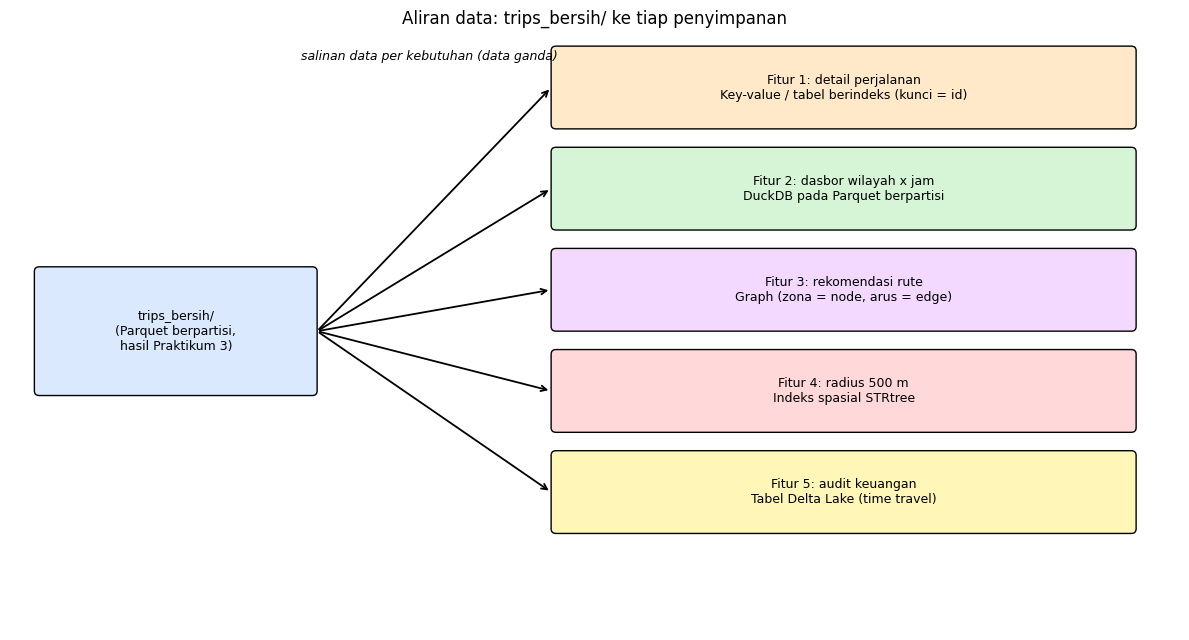

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6.5))
ax.set_xlim(0, 12); ax.set_ylim(0, 6.5); ax.axis("off")

def kotak_(x, y, w, h, teks, warna):
    ax.add_patch(plt.matplotlib.patches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.05", fc=warna, ec="black"))
    ax.text(x + w / 2, y + h / 2, teks, ha="center", va="center", fontsize=9)

def panah(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="->", lw=1.3))

kotak_(0.3, 2.6, 2.8, 1.3, "trips_bersih/\n(Parquet berpartisi,\nhasil Praktikum 3)", "#dbe9ff")

target = [
    ("Fitur 1: detail perjalanan\nKey-value / tabel berindeks (kunci = id)", "#ffe9c9", 5.5),
    ("Fitur 2: dasbor wilayah x jam\nDuckDB pada Parquet berpartisi", "#d6f5d6", 4.4),
    ("Fitur 3: rekomendasi rute\nGraph (zona = node, arus = edge)", "#f3d9ff", 3.3),
    ("Fitur 4: radius 500 m\nIndeks spasial STRtree", "#ffd9d9", 2.2),
    ("Fitur 5: audit keuangan\nTabel Delta Lake (time travel)", "#fff6b8", 1.1),
]
for teks, warna, y in target:
    kotak_(5.6, y, 5.9, 0.8, teks, warna)
    panah(3.15, 3.25, 5.55, y + 0.4)

ax.text(4.3, 6.2, "salinan data per kebutuhan (data ganda)", ha="center", fontsize=9, style="italic")
plt.title("Aliran data: trips_bersih/ ke tiap penyimpanan", fontsize=12)
plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/diagram_aliran_data.png", dpi=200)
plt.show()

P-6. Menjaga data ganda tetap sama (untuk paragraf data ganda)

In [ ]:
# Pemeriksaan rekonsiliasi: dua salinan yang sama harus memberi jumlah baris dan checksum sama
def rekonsiliasi():
    n_sql, s_sql = con.execute("SELECT COUNT(*), ROUND(SUM(total_bayar), 2) FROM perjalanan").fetchone()
    n_kv = len(kv)
    s_kv = round(sum(json.loads(v)["total_bayar"] for v in kv.values()), 2)
    print(f"tabel SQL : {n_sql:,} baris | checksum total_bayar = {s_sql:,.2f}")
    print(f"key-value : {n_kv:,} baris | checksum total_bayar = {s_kv:,.2f}")
    print("KONSISTEN?", n_sql == n_kv and abs(s_sql - s_kv) < 0.01)

# Pola tulis ganda: satu fungsi mengubah KEDUA salinan
def ubah_total(id_, total_baru):
    con.execute("UPDATE perjalanan SET total_bayar = ? WHERE id_perjalanan = ?", (total_baru, id_))
    d = json.loads(kv[f"perjalanan:{id_}"])
    d["total_bayar"] = total_baru
    kv[f"perjalanan:{id_}"] = json.dumps(d)
    con.commit()

rekonsiliasi()
asal = con.execute("SELECT total_bayar FROM perjalanan WHERE id_perjalanan = 1").fetchone()[0]
ubah_total(1, asal + 100)   # demo: ubah di kedua salinan
rekonsiliasi()
ubah_total(1, asal)         # kembalikan
rekonsiliasi()

tabel SQL : 300,000 baris | checksum total_bayar = 8,195,976.28
key-value : 300,000 baris | checksum total_bayar = 8,195,976.28
KONSISTEN? True
tabel SQL : 300,000 baris | checksum total_bayar = 8,196,076.28
key-value : 300,000 baris | checksum total_bayar = 8,196,076.28
KONSISTEN? True
tabel SQL : 300,000 baris | checksum total_bayar = 8,195,976.28
key-value : 300,000 baris | checksum total_bayar = 8,195,976.28
KONSISTEN? True


Latihan

Latihan 1: 2.000 id acak (indeks vs key-value, µs per pencarian)

In [ ]:
random.seed(7)
id_2000 = random.sample(range(1, len(data) + 1), 2000)

def cari_sql_2000():
    cur = con.cursor()
    return [cur.execute("SELECT * FROM perjalanan WHERE id_perjalanan = ?", (i,)).fetchone() for i in id_2000]

def cari_kv_2000():
    return [json.loads(kv[f"perjalanan:{i}"]) for i in id_2000]

ukur("L1 cari 2000 - SQL dengan indeks", cari_sql_2000)
ukur("L1 cari 2000 - key-value", cari_kv_2000)

for lbl in ("L1 cari 2000 - SQL dengan indeks", "L1 cari 2000 - key-value"):
    print(f"{lbl}: {waktu(lbl) / 2000 * 1e6:,.2f} µs per pencarian")

[L1 cari 2000 - SQL dengan indeks] 0.1164 s
[L1 cari 2000 - key-value] 0.0697 s
L1 cari 2000 - SQL dengan indeks: 58.20 µs per pencarian
L1 cari 2000 - key-value: 34.85 µs per pencarian


Latihan 2: dokumen vs SQL untuk zona tujuan tertentu + "Tunai"

In [ ]:
Z = int(sample.head(20_000)["zona_tujuan"].mode()[0])
print("zona tujuan yang diuji:", Z)

n_doc = len(tabel.search((Q.tujuan.zona == Z) & (Q.biaya.metode_bayar == "Tunai")))
n_sql_penuh = con.execute(
    "SELECT COUNT(*) FROM perjalanan WHERE zona_tujuan = ? AND metode_bayar = 'Tunai'", (Z,)).fetchone()[0]
n_sql_20k = con.execute(
    "SELECT COUNT(*) FROM perjalanan WHERE zona_tujuan = ? AND metode_bayar = 'Tunai' AND id_perjalanan <= 20000",
    (Z,)).fetchone()[0]

print("TinyDB (20.000 dokumen)            :", n_doc)
print("SQL tabel penuh (300.000 baris)    :", n_sql_penuh)
print("SQL dibatasi id <= 20000           :", n_sql_20k)
print("sama (TinyDB vs SQL penuh)?        :", n_doc == n_sql_penuh)
print("sama (TinyDB vs SQL id <= 20000)?  :", n_doc == n_sql_20k)

zona tujuan yang diuji: 236
TinyDB (20.000 dokumen)            : 155
SQL tabel penuh (300.000 baris)    : 2074
SQL dibatasi id <= 20000           : 155
sama (TinyDB vs SQL penuh)?        : False
sama (TinyDB vs SQL id <= 20000)?  : True


Latihan 3: SUM satu kolom vs beberapa kolom (column pruning)

In [ ]:
SUM_1 = "SELECT SUM(total_bayar) FROM perjalanan"
SUM_2 = "SELECT SUM(total_bayar), SUM(jarak_mil) FROM perjalanan"
SUM_4 = """SELECT SUM(total_bayar), SUM(jarak_mil),
                  SUM(zona_jemput::DOUBLE), SUM(zona_tujuan::DOUBLE) FROM perjalanan"""

hasil_l3 = {}
for nama, q in [("1 kolom", SUM_1), ("2 kolom", SUM_2), ("4 kolom", SUM_4)]:
    hasil_l3[nama] = ulang(lambda q=q: con_d.sql(q).fetchall())
    catatan.append({"langkah": f"L3 DuckDB SUM {nama}", "detik": round(hasil_l3[nama], 4)})
    print(f"SUM {nama}: {hasil_l3[nama]*1000:.2f} ms")

print(f"\n4 kolom / 1 kolom = {hasil_l3['4 kolom'] / hasil_l3['1 kolom']:.2f}x")
print(f"2 kolom / 1 kolom = {hasil_l3['2 kolom'] / hasil_l3['1 kolom']:.2f}x")

SUM 1 kolom: 598.90 ms
SUM 2 kolom: 306.32 ms
SUM 4 kolom: 375.12 ms

4 kolom / 1 kolom = 0.63x
2 kolom / 1 kolom = 0.51x


Latihan 4: lima zona dengan tujuan berbeda terbanyak (graph vs SQL)

In [ ]:
top_graf = sorted(G.out_degree(), key=lambda kv_: (-kv_[1], kv_[0]))[:5]
top_sql_df = con_d.sql("""
    SELECT zona_jemput AS zona, COUNT(DISTINCT zona_tujuan) AS jumlah_tujuan
    FROM perjalanan GROUP BY 1 ORDER BY 2 DESC, 1 LIMIT 5""").df()
top_sql = [tuple(r) for r in top_sql_df.itertuples(index=False, name=None)]

print("graph (out-degree):", top_graf)
print("SQL (COUNT DISTINCT):", top_sql)
print("sama?", [(int(a), int(b)) for a, b in top_graf] == [(int(a), int(b)) for a, b in top_sql])

graph (out-degree): [(132, 260), (138, 254), (264, 241), (230, 234), (140, 233)]
SQL (COUNT DISTINCT): [(132, 260), (138, 254), (264, 241), (230, 234), (140, 233)]
sama? True


Latihan 5: ukuran kotak 0,02 dan 0,001 derajat

In [ ]:
def uji_sisi(sisi):
    h = sisi / 2
    kt = [box(x - h, y - h, x + h, y + h) for x, y in zip(cx, cy)]

    def pakai_numpy():
        out = []
        for x, y in zip(cx, cy):
            m = (bujur >= x - h) & (bujur <= x + h) & (lintang >= y - h) & (lintang <= y + h)
            out.append(int(m.sum()))
        return out

    def pakai_idx():
        return [len(pohon.query(k, predicate="contains")) for k in kt]

    hn = ukur(f"L5 NumPy sisi {sisi}", pakai_numpy)
    hi = ukur(f"L5 STRtree sisi {sisi}", pakai_idx)
    return {
        "sisi (derajat)": sisi,
        "titik ditemukan": sum(hi),
        "NumPy (s)": waktu(f"L5 NumPy sisi {sisi}"),
        "STRtree cari (s)": waktu(f"L5 STRtree sisi {sisi}"),
        "NumPy/STRtree (cari saja)": round(waktu(f"L5 NumPy sisi {sisi}") / waktu(f"L5 STRtree sisi {sisi}"), 2),
        "NumPy/STRtree (+bangun)": round(waktu(f"L5 NumPy sisi {sisi}") /
                                         (waktu(f"L5 STRtree sisi {sisi}") + waktu("bangun indeks STRtree")), 2),
        "hasil sama?": hn == hi,
    }

tabel_l5 = pd.DataFrame([uji_sisi(s) for s in (0.02, 0.01, 0.001)])
print(tabel_l5.to_string(index=False))

[L5 NumPy sisi 0.02] 1.9479 s
[L5 STRtree sisi 0.02] 1.8826 s
[L5 NumPy sisi 0.01] 0.5473 s
[L5 STRtree sisi 0.01] 0.3169 s
[L5 NumPy sisi 0.001] 0.5646 s
[L5 STRtree sisi 0.001] 0.0136 s
 sisi (derajat)  titik ditemukan  NumPy (s)  STRtree cari (s)  NumPy/STRtree (cari saja)  NumPy/STRtree (+bangun)  hasil sama?
          0.020          1666631     1.9479            1.8826                       1.03                     0.99         True
          0.010           417545     0.5473            0.3169                       1.73                     1.33         True
          0.001             4149     0.5646            0.0136                      41.51                     5.26         True


Tugas Praktikum

R1. Rekap benchmark (tabel K-9 terisi angka sendiri)

In [ ]:
nk = len(tabel.search(Q.biaya.tip.exists()))
nt = len(tabel.search(~Q.biaya.tip.exists()))
jangkauan = {k: len(nx.single_source_shortest_path_length(H, zona_awal, cutoff=k)) - 1 for k in (1, 2, 3, 4)}
versi_delta = DeltaTable(PATH_DELTA).version()

rekap_k9 = pd.DataFrame([
    {"kebutuhan": "Ambil satu data lewat id",
     "unggul": "Key-value; tabel dengan indeks", "lemah": "Tabel tanpa indeks",
     "angka": (f"tanpa indeks {waktu('cari 200 perjalanan - SQL tanpa indeks'):.4f} s; "
               f"indeks {waktu('cari 200 perjalanan - SQL dengan indeks'):.4f} s; "
               f"key-value {waktu('cari 200 perjalanan - key-value'):.4f} s (200 pencarian)")},
    {"kebutuhan": "Menghitung/merangkum banyak baris",
     "unggul": "Per kolom (DuckDB pada Parquet)", "lemah": "Key-value (buka semua nilai)",
     "angka": (f"DuckDB {waktu('DuckDB - hitung per wilayah (langsung dari Parquet)'):.4f} s; "
               f"SQLite {waktu('SQLite - hitung per wilayah'):.4f} s; "
               f"SQL GROUP BY {waktu('hitung per wilayah - SQL GROUP BY'):.4f} s; "
               f"key-value {waktu('hitung per wilayah - key-value (buka semua nilai)'):.4f} s")},
    {"kebutuhan": "Data dengan field opsional/berubah",
     "unggul": "Document", "lemah": "Tabel (kolom NULL, migrasi)",
     "angka": f"{nt:,} dokumen tanpa field tip, {nk:,} dengan tip; 1 dokumen membawa field cuaca tanpa migrasi"},
    {"kebutuhan": "Keterhubungan, jumlah langkah bebas",
     "unggul": "Graph", "lemah": "SQL (satu JOIN per langkah)",
     "angka": (f"2 langkah: graph {waktu('2 langkah - graph (NetworkX)'):.4f} s, "
               f"SQL {waktu('2 langkah - SQL self-join (DuckDB)'):.4f} s; "
               f"zona terjangkau k=1..4: {list(jangkauan.values())}")},
    {"kebutuhan": "Mencari lokasi dalam wilayah",
     "unggul": "Spasial dengan indeks", "lemah": "Memeriksa semua titik",
     "angka": (f"loop 5 kotak {waktu('cara 1 - loop Python, 5 kotak'):.4f} s; "
               f"NumPy {waktu('cara 2 - NumPy, 1000 kotak'):.4f} s; "
               f"STRtree {waktu('bangun indeks STRtree') + waktu('cara 3 - STRtree, 1000 kotak'):.4f} s "
               f"(bangun + cari, 1000 kotak)")},
    {"kebutuhan": "Perubahan aman dan bisa dibatalkan",
     "unggul": "Tabel Delta", "lemah": "Folder Parquet biasa",
     "angka": f"{versi_delta + 1} versi di _delta_log; kolom asing ditolak (SchemaMismatchError), versi tidak berubah"},
])
rekap_k9["interpretasi"] = ""   # <- isi satu kalimat per baris (bisa dibantu nanti)

rekap_k9.to_csv(f"{DIR_SIMPAN}/rekap_k9.csv", index=False)
pd.set_option("display.max_colwidth", None)
print(rekap_k9.to_string(index=False))

# Simpan ulang benchmark lengkap (sudah memuat semua ukuran dari O, P, Q)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/benchmark_nosql.csv", index=False)
print("\nbenchmark_nosql.csv tersimpan ulang:", len(catatan), "baris")

                          kebutuhan                          unggul                        lemah                                                                                         angka interpretasi
           Ambil satu data lewat id  Key-value; tabel dengan indeks           Tabel tanpa indeks                    tanpa indeks 6.9061 s; indeks 0.0042 s; key-value 0.0014 s (200 pencarian)             
  Menghitung/merangkum banyak baris Per kolom (DuckDB pada Parquet) Key-value (buka semua nilai)                   DuckDB 0.2660 s; SQLite 4.4387 s; SQL GROUP BY 0.2002 s; key-value 1.2710 s             
 Data dengan field opsional/berubah                        Document  Tabel (kolom NULL, migrasi) 4,094 dokumen tanpa field tip, 15,907 dengan tip; 1 dokumen membawa field cuaca tanpa migrasi             
Keterhubungan, jumlah langkah bebas                           Graph  SQL (satu JOIN per langkah)          2 langkah: graph 0.0095 s, SQL 0.0174 s; zona terjangkau k=1..4: [74, 214, 214

R2. Data lain, cara lain: data "zona" (tabel, document, graph)

In [ ]:
zona_df = con_d.sql("""
    SELECT zona_jemput AS zona, mode(wilayah_jemput) AS wilayah,
           COUNT(*) AS jumlah_jemput, ROUND(AVG(total_bayar), 2) AS rata_bayar
    FROM perjalanan GROUP BY 1 ORDER BY 1""").df()

top_tujuan = con_d.sql("""
    SELECT asal AS zona, tujuan, jumlah FROM arus
    QUALIFY ROW_NUMBER() OVER (PARTITION BY asal ORDER BY jumlah DESC, tujuan) <= 3""").df()
print("zona:", len(zona_df))

# ---------- (1) TABEL ----------
con_z = sqlite3.connect(":memory:")
zona_df.to_sql("zona", con_z, index=False)
arus.to_sql("arus", con_z, index=False)

# MUDAH: zona terpadat per wilayah
print("\n[Tabel] MUDAH - zona dengan jemputan terbanyak per wilayah")
print(con_z.execute("""
    SELECT wilayah, zona, jumlah_jemput FROM zona z
    WHERE jumlah_jemput = (SELECT MAX(jumlah_jemput) FROM zona WHERE wilayah = z.wilayah)
    ORDER BY jumlah_jemput DESC""").fetchall())

# CANGGUNG: zona yang bisa dicapai dalam 3 langkah -> dua self-join
print("[Tabel] CANGGUNG - zona terjangkau tepat 3 langkah dari", zona_awal)
r_tabel = con_z.execute(f"""
    SELECT DISTINCT a3.tujuan FROM arus a1
    JOIN arus a2 ON a1.tujuan = a2.asal JOIN arus a3 ON a2.tujuan = a3.asal
    WHERE a1.asal = {zona_awal} AND a1.jumlah >= {MIN} AND a2.jumlah >= {MIN}
      AND a3.jumlah >= {MIN} AND a3.tujuan <> {zona_awal}""").fetchall()
print("jumlah zona:", len(r_tabel))

# ---------- (2) DOCUMENT ----------
from collections import defaultdict
tt = defaultdict(list)
for r in top_tujuan.itertuples(index=False):
    tt[int(r.zona)].append({"zona": int(r.tujuan), "jumlah": int(r.jumlah)})

dz = TinyDB(storage=MemoryStorage).table("zona")
dz.insert_multiple([
    {"zona": int(r.zona), "wilayah": r.wilayah,
     "statistik": {"jumlah_jemput": int(r.jumlah_jemput), "rata_bayar": float(r.rata_bayar)},
     "top_tujuan": tt.get(int(r.zona), [])}
    for r in zona_df.itertuples(index=False)])

Qz = Query()
print("\n[Document] MUDAH - satu zona beserta tujuan teratasnya (satu kali baca)")
print(json.dumps(dz.get(Qz.zona == int(zona_awal)), indent=1))

print("[Document] CANGGUNG - zona mana yang punya zona", zona_awal, "sebagai tujuan TERATAS (scan semua dokumen)")
hasil_doc = dz.search(Qz.top_tujuan.test(lambda lst: bool(lst) and lst[0]["zona"] == int(zona_awal)))
print("zona:", [d["zona"] for d in hasil_doc])

# ---------- (3) GRAPH ----------
for r in zona_df.itertuples(index=False):
    if int(r.zona) in G:
        G.nodes[int(r.zona)].update(wilayah=r.wilayah, jumlah_jemput=int(r.jumlah_jemput),
                                    rata_bayar=float(r.rata_bayar))

print("\n[Graph] MUDAH - zona terjangkau dalam <= k langkah dari", zona_awal)
print({k: len(nx.single_source_shortest_path_length(H, zona_awal, cutoff=k)) - 1 for k in (1, 2, 3)})

print("[Graph] CANGGUNG - rata-rata total_bayar per wilayah (harus dihitung manual dari atribut node)")
tot, jml = defaultdict(float), defaultdict(int)
for n, a in G.nodes(data=True):
    if "wilayah" in a:
        tot[a["wilayah"]] += a["rata_bayar"] * a["jumlah_jemput"]
        jml[a["wilayah"]] += a["jumlah_jemput"]
print({w: round(tot[w] / jml[w], 2) for w in jml})

zona: 254

[Tabel] MUDAH - zona dengan jemputan terbanyak per wilayah
[('Queens', 132, 152840), ('Manhattan', 237, 145797), ('Unknown', 264, 37609), ('Brooklyn', 65, 1452), ('__HIVE_DEFAULT_PARTITION__', 265, 340), ('Bronx', 168, 228), ('Staten Island', 23, 79), ('EWR', 1, 28)]
[Tabel] CANGGUNG - zona terjangkau tepat 3 langkah dari 236
jumlah zona: 214

[Document] MUDAH - satu zona beserta tujuan teratasnya (satu kali baca)
{
 "zona": 236,
 "wilayah": "Manhattan",
 "statistik": {
  "jumlah_jemput": 136276,
  "rata_bayar": 20.64
 },
 "top_tujuan": [
  {
   "zona": 237,
   "jumlah": 18810
  },
  {
   "zona": 236,
   "jumlah": 14110
  },
  {
   "zona": 161,
   "jumlah": 7497
  }
 ]
}
[Document] CANGGUNG - zona mana yang punya zona 236 sebagai tujuan TERATAS (scan semua dokumen)
zona: [75, 140, 141, 163, 237, 262]

[Graph] MUDAH - zona terjangkau dalam <= k langkah dari 236
{1: 74, 2: 214, 3: 214}
[Graph] CANGGUNG - rata-rata total_bayar per wilayah (harus dihitung manual dari atribut nod

R3. Delta Lake dua hari

In [ ]:
PATH_2HARI = "/content/trips_delta_2hari"   # disk lokal (Drive tidak mendukung rename atomik)
if os.path.exists(PATH_2HARI):
    shutil.rmtree(PATH_2HARI)

# ---------- HARI 1: menulis sebagian data ----------
write_deltalake(PATH_2HARI, data_delta.iloc[:80_000], mode="overwrite")
dt2 = DeltaTable(PATH_2HARI)
versi_akhir_hari1 = dt2.version()
d1 = dt2.to_pandas()
ringkas_hari1 = (len(d1), round(d1["total_bayar"].sum(), 2))
print("HARI 1 | versi:", versi_akhir_hari1, "| baris:", ringkas_hari1[0], "| total_bayar:", ringkas_hari1[1])

# ---------- HARI 2: menambah data + mengoreksi beberapa baris ----------
write_deltalake(PATH_2HARI, data_delta.iloc[80_000:120_000], mode="append")
dt2 = DeltaTable(PATH_2HARI)

n_koreksi2 = int(((data_delta.iloc[:120_000]["wilayah_jemput"] == "Queens") &
                  (data_delta.iloc[:120_000]["metode_bayar"] == "Tunai")).sum())
dt2.update(predicate="wilayah_jemput = 'Queens' AND metode_bayar = 'Tunai'",
           updates={"total_bayar": "total_bayar + 2.0"})
dt2 = DeltaTable(PATH_2HARI)
terbaru = dt2.to_pandas()
print("HARI 2 | versi:", dt2.version(), "| baris:", len(terbaru),
      "| total_bayar:", round(terbaru["total_bayar"].sum(), 2), "| baris dikoreksi:", n_koreksi2)

# ---------- Baca tabel seperti keadaan di akhir hari pertama ----------
akhir_hari1 = DeltaTable(PATH_2HARI, version=versi_akhir_hari1).to_pandas()
print("\nKeadaan akhir hari 1 (time travel ke versi", versi_akhir_hari1, "):",
      len(akhir_hari1), "baris | total_bayar", round(akhir_hari1["total_bayar"].sum(), 2))
print("sama dengan yang dicatat di hari 1?", (len(akhir_hari1), round(akhir_hari1["total_bayar"].sum(), 2)) == ringkas_hari1)

# ---------- Riwayat dan isi _delta_log ----------
print("\nRiwayat:", [(h.get("version"), h.get("operation")) for h in dt2.history()])
print("\nBerkas _delta_log:", sorted(os.listdir(f"{PATH_2HARI}/_delta_log")))

with open(f"{DIR_SIMPAN}/delta_log_dua_hari.txt", "w") as out:
    for nama in sorted(os.listdir(f"{PATH_2HARI}/_delta_log")):
        if not nama.endswith(".json"):
            continue
        isi = open(f"{PATH_2HARI}/_delta_log/{nama}").read()
        out.write(f"===== {nama} =====\n{isi}\n")
        print(f"\n===== {nama} =====")
        for baris in isi.strip().splitlines():
            print(baris[:300] + (" ..." if len(baris) > 300 else ""))

# ---------- Simpan ke Drive (lampiran) ----------
shutil.copytree(f"{PATH_2HARI}/_delta_log", f"{DIR_SIMPAN}/delta_log_dua_hari", dirs_exist_ok=True)
arsip2 = shutil.make_archive(f"{DIR_SIMPAN}/trips_delta_2hari", "zip", PATH_2HARI)
print("\ntersimpan:", arsip2)

HARI 1 | versi: 0 | baris: 80000 | total_bayar: 2192717.95
HARI 2 | versi: 2 | baris: 120000 | total_bayar: 3292030.43 | baris dikoreksi: 2458

Keadaan akhir hari 1 (time travel ke versi 0 ): 80000 baris | total_bayar 2192717.95
sama dengan yang dicatat di hari 1? True

Riwayat: [(2, 'UPDATE'), (1, 'WRITE'), (0, 'WRITE')]

Berkas _delta_log: ['00000000000000000000.json', '00000000000000000001.json', '00000000000000000002.json']

===== 00000000000000000000.json =====
{"commitInfo":{"timestamp":1791198920904,"operation":"WRITE","operationParameters":{"mode":"Overwrite"},"engineInfo":"delta-rs:py-1.6.6","clientVersion":"delta-rs.py-1.6.6","operationMetrics":{"num_added_files":1,"num_removed_files":0,"num_partitions":0,"num_added_rows":80000,"execution_time_ms":83, ...
{"protocol":{"minReaderVersion":3,"minWriterVersion":7,"readerFeatures":["timestampNtz"],"writerFeatures":["timestampNtz"]}}
{"metaData":{"id":"3e3e4e42-39e5-43bf-a148-28d5e6de97b3","name":null,"description":null,"format":{"

In [ ]:
# Salin hasil ke Drive sebagai arsip zip (tugas meminta trips_delta.zip)
arsip = shutil.make_archive(f"{DIR_SIMPAN}/trips_delta", "zip", PATH_DELTA)
print("arsip tersimpan:", arsip)

arsip tersimpan: /content/drive/MyDrive/BigData/Praktikum4/trips_delta.zip


Latihan 6: restore vs time travel (jalankan paling akhir)

In [ ]:
dt = DeltaTable(PATH_DELTA)
print("versi sebelum restore:", dt.version(), "| baris:", len(dt.to_pandas()))

# Time travel hanya MEMBACA: versi tabel tidak berubah
_ = DeltaTable(PATH_DELTA, version=1).to_pandas()
print("versi setelah time travel (baca v1):", DeltaTable(PATH_DELTA).version())

dt.restore(1)  # kembalikan tabel ke keadaan versi 1 (dicatat sebagai versi baru)
dt = DeltaTable(PATH_DELTA)
print("versi setelah restore:", dt.version(), "| baris:", len(dt.to_pandas()))
print([h.get("operation") for h in dt.history()][:3])

# Riwayat lama masih utuh: versi 23 (sebelum restore) tetap bisa dibaca
print("baris pada versi 23 (sebelum restore):", len(DeltaTable(PATH_DELTA, version=23).to_pandas()))

versi sebelum restore: 23 | baris: 160000
versi setelah time travel (baca v1): 23
versi setelah restore: 24 | baris: 150000
['RESTORE', 'OPTIMIZE', 'WRITE']
baris pada versi 23 (sebelum restore): 160000


In [ ]:
# Simpan ulang benchmark terakhir
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/benchmark_nosql.csv", index=False)

# Cek berkas yang akan dikumpulkan
wajib = ["benchmark_nosql.csv", "trips_delta.zip", "rekap_k9.csv",
         "diagram_aliran_data.png", "trips_delta_2hari.zip", "delta_log_dua_hari.txt"]
for nama in wajib:
    p = f"{DIR_SIMPAN}/{nama}"
    if os.path.exists(p):
        print(f"OK     {nama:28s} {os.path.getsize(p)/1024:,.1f} KB")
    else:
        print(f"HILANG {nama}")
print("\nIsi folder Praktikum4:", sorted(os.listdir(DIR_SIMPAN)))

OK     benchmark_nosql.csv          1.3 KB
OK     trips_delta.zip              5,859.4 KB
OK     rekap_k9.csv                 1.0 KB
OK     diagram_aliran_data.png      163.3 KB
OK     trips_delta_2hari.zip        3,073.0 KB
OK     delta_log_dua_hari.txt       4.9 KB

Isi folder Praktikum4: ['benchmark_nosql.csv', 'delta_log_dua_hari', 'delta_log_dua_hari.txt', 'diagram_aliran_data.png', 'rekap_k9.csv', 'trips_delta', 'trips_delta.zip', 'trips_delta_2hari.zip']


In [ ]:
import time

menit = 0
print("Menjaga runtime... Tekan tombol Stop (◼) di samping sel untuk mematikan.")

try:
    while True:
        # Kode akan terus berulang di dalam blok ini
        time.sleep(60)
        menit += 1
        print(f"Menjaga runtime tetap aktif... ({menit} menit berlalu)")

except KeyboardInterrupt:
    # Blok ini akan tereksekusi saat Anda menekan tombol Stop
    print(f"\n✅ Perulangan dihentikan secara manual. Total waktu berjalan: {menit} menit.")

Menjaga runtime... Tekan tombol Stop (◼) di samping sel untuk mematikan.
Menjaga runtime tetap aktif... (1 menit berlalu)
Menjaga runtime tetap aktif... (2 menit berlalu)
Menjaga runtime tetap aktif... (3 menit berlalu)
Menjaga runtime tetap aktif... (4 menit berlalu)
Menjaga runtime tetap aktif... (5 menit berlalu)
Menjaga runtime tetap aktif... (6 menit berlalu)
Menjaga runtime tetap aktif... (7 menit berlalu)
Menjaga runtime tetap aktif... (8 menit berlalu)
Menjaga runtime tetap aktif... (9 menit berlalu)
Menjaga runtime tetap aktif... (10 menit berlalu)
Menjaga runtime tetap aktif... (11 menit berlalu)
Menjaga runtime tetap aktif... (12 menit berlalu)
Menjaga runtime tetap aktif... (13 menit berlalu)
Menjaga runtime tetap aktif... (14 menit berlalu)
Menjaga runtime tetap aktif... (15 menit berlalu)
Menjaga runtime tetap aktif... (16 menit berlalu)
Menjaga runtime tetap aktif... (17 menit berlalu)
Menjaga runtime tetap aktif... (18 menit berlalu)
Menjaga runtime tetap aktif... (19 m